In [1]:

import numpy as np
import healpy as hp
from tqdm import tqdm
import os
from astropy.table import Table
import sys
import time
import pandas as pd
import dustmaps.sfd
#dustmaps.sfd.fetch()

# Custom script imports
#sys.path.append('/Users/mncavieres/Documents/2024-2/HVS/Classify')
from selections import *
from iterative_correction import implied_calculations
from prepare_gaia_iterative import prepare_gaia_iterative, prepare_speedystar
from classifier_CMD import HistogramClassifier2D

/Users/mncavieres/opt/anaconda3/envs/speedytest2/lib/python3.12/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


In [2]:
import matplotlib.pyplot as plt
# setup the plotting
# set up the plotting
# set font size
plt.rcParams.update({'font.size': 18})
# set the figure size
plt.rcParams.update({'figure.figsize': (10, 7)})
# set the font to latex
plt.rcParams.update({'text.usetex': True})

# Load the LAMOST DR9 catalog

# Load the DESI catalog crossmatched with the distances

In [3]:
desi_dist = Table.read('/Users/mncavieres/Documents/2025-1/DESI_HVS/Data/DESI/distxDESI.fits')

In [4]:
print(desi_dist.colnames)

['TARGETID_1', 'SOURCE_ID', 'RA', 'DEC', 'PMRA', 'PMRA_ERR', 'PMDEC', 'PMDEC_ERR', 'VRAD_1', 'DIST', 'DISTERR', 'MG_NN', 'MG_GEO', 'PARALLAX', 'PARALLAX_ERR', 'PARALLAX_ZPC', 'EBV', 'A_G', 'RUWE', 'APS', 'NEUIA', 'P_COLOUR', 'ECL_LAT', 'BINARY_FLAG', 'VRAD_2', 'VRAD_ERR', 'VRAD_SKEW', 'VRAD_KURT', 'LOGG', 'TEFF', 'ALPHAFE', 'FEH', 'LOGG_ERR', 'TEFF_ERR', 'ALPHAFE_ERR', 'FEH_ERR', 'VSINI', 'CHISQ_TOT', 'CHISQ_C_TOT', 'CHISQ_B', 'CHISQ_C_B', 'CHISQ_R', 'CHISQ_C_R', 'CHISQ_Z', 'CHISQ_C_Z', 'RVS_WARN', 'REF_ID', 'REF_CAT', 'TARGET_RA', 'TARGET_DEC', 'TARGETID_2', 'SN_B', 'SN_R', 'SN_Z', 'SUCCESS', 'RR_Z', 'RR_SPECTYPE', 'HEALPIX', 'SURVEY', 'PROGRAM', 'PRIMARY']


In [5]:
# rename gaia columns to the standard format that is used in the code
desi_dist.rename_column('RA', 'ra')
desi_dist.rename_column('DEC', 'dec')
desi_dist.rename_column('PARALLAX', 'parallax')
desi_dist.rename_column('PARALLAX_ERR', 'parallax_error')
desi_dist.rename_column('PMRA', 'pmra')
desi_dist.rename_column('PMDEC', 'pmdec')
desi_dist.rename_column('PMRA_ERR', 'pmra_error')
desi_dist.rename_column('PMDEC_ERR', 'pmdec_error')



In [6]:
processed = implied_calculations(desi_dist)

  0%|          | 0/10 [00:00<?, ?it/s]/Users/mncavieres/opt/anaconda3/envs/speedytest2/lib/python3.12/site-packages/astropy/units/quantity.py:671: RuntimeWarning: invalid value encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/Users/mncavieres/opt/anaconda3/envs/speedytest2/lib/python3.12/site-packages/astropy/units/quantity.py:671: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
100%|██████████| 10/10 [01:12<00:00,  7.20s/it]


In [7]:
processed.write('/Users/mncavieres/Documents/2025-1/DESI_HVS/Data/DESI/distxDESI_processed.fits', overwrite=True)

# Load Bailer - Jones distances

DESI distances are horrendous

In [10]:
processed = Table.read('/Users/mncavieres/Documents/2025-1/DESI_HVS/Data/DESI/distxDESI_processedxBJ_distances.fits')

In [13]:
processed['rgeo_err'] = (processed['B_rgeo_xa'] - processed['b_rgeo_x'])/2

In [14]:
processed

TARGETID_1,SOURCE_ID,ra,dec,pmra,pmra_error,pmdec,pmdec_error,VRAD_1,DIST,DISTERR,MG_NN,MG_GEO,parallax,parallax_error,PARALLAX_ZPC,EBV,A_G,RUWE,APS,NEUIA,P_COLOUR,ECL_LAT,BINARY_FLAG,VRAD_2,VRAD_ERR,VRAD_SKEW,VRAD_KURT,LOGG,TEFF,ALPHAFE,FEH,LOGG_ERR,TEFF_ERR,ALPHAFE_ERR,FEH_ERR,VSINI,CHISQ_TOT,CHISQ_C_TOT,CHISQ_B,CHISQ_C_B,CHISQ_R,CHISQ_C_R,CHISQ_Z,CHISQ_C_Z,RVS_WARN,REF_ID,REF_CAT,TARGET_RA,TARGET_DEC,TARGETID_2,SN_B,SN_R,SN_Z,SUCCESS,RR_Z,RR_SPECTYPE,HEALPIX,SURVEY,PROGRAM,PRIMARY,implied_parallax,implied_parallax_error,VGCR,VR,implied_distance,implied_distance_error,x,y,z,vx,vy,vz,V_gcr_desi,Lz,Lx,Ly,kinetic_energy,R,potential_energy,total_energy,Source,RA_ICRS,DE_ICRS,rgeo,b_rgeo_x,B_rgeo_xa,rpgeo,b_rpgeo_x,B_rpgeo_xa,Flag,angDist,rgeo_err
,,deg,deg,mas / yr,mas / yr,mas / yr,mas / yr,km / s,kpc,kpc,,,mas,mas,mas,,,,,,,,,km / s,km / s,,,,K,,,,K,,,km / s,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,deg,deg,pc,pc,pc,pc,pc,pc,,arcsec,pc
int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,bytes2,float64,float64,int64,float32,float32,float32,bool,float64,bytes6,int64,bytes7,bytes6,bool,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,float64,float64,float64,float64,float64,float64,float64,float64,int16,float64,float64
39628530270601815,303977276742747520,25.15985919133296,32.408637808060924,-0.8485930999414718,0.07491044700145721,-2.6749580897152576,0.07131846994161606,-20.49015752697828,4.8986983753066005,0.6119278930549013,3.4830634593963623,3.586488350850791,0.21409389265164538,0.06846439838409424,-0.02969999983906746,0.04494500160217285,0.12246222596807854,1.0351929664611816,31.0,1.5734182596206665,--,20.42341380050078,1,-20.49015752697828,0.3688007339341279,0.0010991605433990114,3.000137002675015,4.571702568260303,6229.5419155054715,0.2594246375562732,-0.7805556661338733,0.028175698845332362,10.5067324767806,0.01123095689540812,0.011705394916506975,0.01,10100.781210439898,94473.54903564173,3654.7827520369938,65969.40749500786,3043.0523549775103,11615.26421720567,3402.946103425395,16888.877323428198,0,303977276742747520,G2,25.15985933676262,32.40863816411243,39628530270601815,73.38309,92.469696,87.60965,True,-7.01337079418114e-05,STAR,2159,cmx,other,True,0.0718853616750429,0.002137276807706652,-688.1406221599956,-791.8373137454972,13911.03802913993,413.59935121712357,-11.139562769184204,3.0286747311560642,-2.370544671856561,51.85371343321997,214.42480234593367,-38.88443368276186,224.00625580714552,-2.5456465765942458,0.39053527098475466,-0.5560771338484028,25089.401320368157,11.54394773531733,-0.9826121270021482,25088.418708241155,303977276742747520,25.15985919133,32.40863780806,3514.59204,2936.20264,4282.29932,3586.38989,3119.76099,4322.854,10033,0.0,673.04834
39628525149358093,303949342275483520,24.931221035274252,32.12666730036334,-3.0189711248875457,0.05783328786492348,-4.0765874468750924,0.05598762258887291,-2.2097139077750056,2.6793122446149336,0.1646240254553316,3.5032734870910645,3.4774245573070193,0.3688135642621595,0.05308822914958,-0.039066001772880554,0.04998999834060669,0.13717036216830625,1.0719799995422363,31.0,1.586361050605774,--,20.23739701958684,1,-2.2097139077750056,0.2269699042465925,0.0007768646699934468,2.999993508899016,4.1601064157342975,6304.115028924883,0.350297005484549,-0.9491301165389585,0.01644218587873275,5.961602293847264,0.007791057717266253,0.007757969080442948,0.01025491077853254,16760.154409109815,322054.88624902116,6628.476548925841,247025.02437501034,4947.476976083158,31006.64851624132,5184.200884100817,44023.21335776949,0,303949342275483520,G2,24.93122154066041

## Add the Galactocentric position and velocities

In [17]:
from galpy.potential import MWPotential2014, evaluatePotentials, McMillan17

In [22]:
# compute the Vgcr using the DESI distances

coords = SkyCoord(ra=processed['ra'], dec=processed['dec'], pm_dec = processed['pmdec'], pm_ra_cosdec = processed['pmra'], distance = processed['rgeo'], radial_velocity = processed['VRAD_1'], frame='icrs')

from astropy.coordinates import Galactocentric
from astropy import units as u

coords_gc = coords.transform_to(Galactocentric)

processed['x'] = coords_gc.x.to(u.kpc).value
processed['y'] = coords_gc.y.to(u.kpc).value
processed['z'] = coords_gc.z.to(u.kpc).value
processed['vx'] = coords_gc.v_x.to(u.km/u.s).value
processed['vy'] = coords_gc.v_y.to(u.km/u.s).value
processed['vz'] = coords_gc.v_z.to(u.km/u.s).value

# compute the Vgcr using the DESI distances
processed['V_gcr_bj'] = np.sqrt(processed['vx']**2 + processed['vy']**2 + processed['vz']**2)

# compute the angular momentum
processed['Lz'] = processed['x'] * processed['vy'] - processed['y'] * processed['vx']
processed['Lz'] = processed['Lz'] #* 1e-3 # convert to kpc km/s
processed['Lx'] = processed['y'] * processed['vz'] - processed['z'] * processed['vy']
processed['Lx'] = processed['Lx'] #* 1e-3 # convert to kpc km/s
processed['Ly'] = processed['z'] * processed['vx'] - processed['x'] * processed['vz']
processed['Ly'] = processed['Ly'] #* 1e-3 # convert to kpc km/s

# compute the energy
# --- Compute the energy ---

# 1. Kinetic energy per unit mass: KE = 0.5 * v^2, in (km/s)^2 units.
processed['kinetic_energy'] = 0.5 * processed['V_gcr_bj']**2

# 2. Prepare to evaluate the gravitational potential.
# The MWPotential2014 potential in galpy returns potential in (km/s)^2.
# We need the cylindrical radius R = sqrt(x^2 + y^2) and z in kpc.
processed['R'] = np.sqrt(processed['x']**2 + processed['y']**2)
R = processed['R'] * u.kpc  # convert to astropy units
z = processed['z'] * u.kpc  # convert to astropy units

# 3. Compute the gravitational potential energy per unit mass.
# Note: The evaluatePotentials function returns the potential energy (Φ) at (R,z).
potential_energy = evaluatePotentials(MWPotential2014, R, z)  # in (km/s)^2
processed['potential_energy'] = -potential_energy

# 4. Total energy per unit mass:
processed['total_energy'] = processed['kinetic_energy'] + processed['potential_energy']


In [23]:
# remove source_id 1314329502328088448 as it is repeated
processed = processed[processed['SOURCE_ID'] != 1314329502328088448]

In [24]:
processed.write('/Users/mncavieres/Documents/2025-1/DESI_HVS/Data/DESI/distxDESI_processed_BJ_angular_momenta.fits', overwrite=True)

In [23]:
# select stars with consistent desi distance to implied distance
processed_consistent = processed[abs(processed['DIST'] - processed['implied_distance']/1e3) < 2*processed['DISTERR']]

# select stars with RVS_WARN == 0
processed_consistent = processed_consistent[processed_consistent['RVS_WARN'] == 0]

# select stars with consistent RV to VR
processed_consistent = processed_consistent[abs(processed_consistent['VR'] - processed_consistent['VRAD_1'] )< 2*processed_consistent['VRAD_ERR']]

## Comparison of spaces

Now we want to characterize both the population of selected stars and the background, to have an idea of the contamination

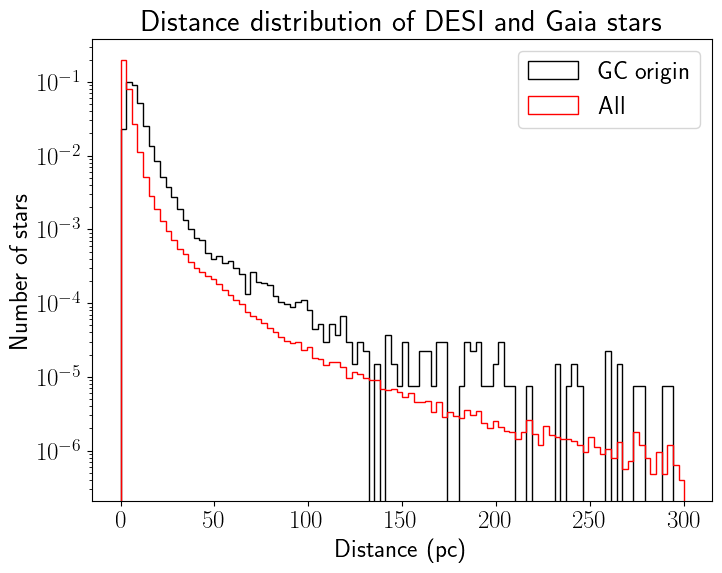

In [30]:
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
plt.hist(processed_consistent['DIST'], bins=100, histtype='step', color='k', label='GC origin', density=True, range=(0, 300), log=True)
plt.hist(processed['DIST'], bins=100, histtype='step', color='r', label='All', density=True, range=(0, 300), log=True)
plt.xlabel('Distance (pc)')
plt.ylabel('Number of stars')
plt.legend()
plt.title('Distance distribution of DESI and Gaia stars')
plt.show()

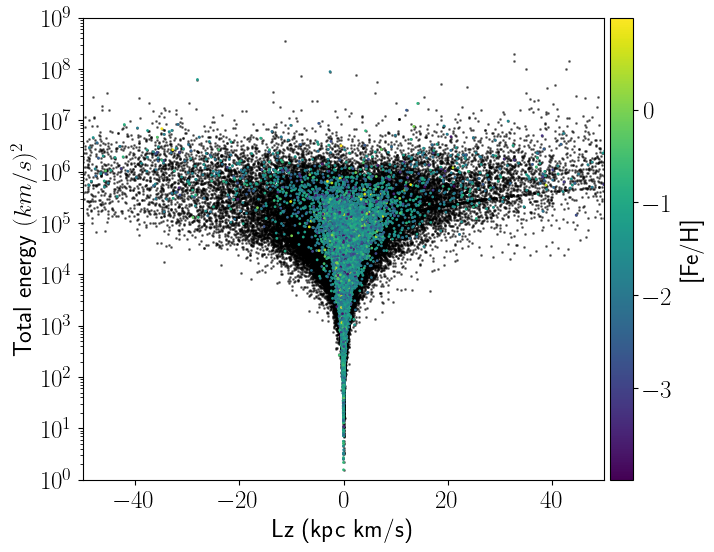

In [51]:
# plot angular momentum vs energy
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
ax.scatter(processed['Lz'], processed['total_energy'], s=1, color='k', alpha=0.5)
cbar = ax.scatter(processed_consistent['Lz'], processed_consistent['total_energy'], s=1, c=processed_consistent['FEH'], alpha=1)
plt.colorbar(cbar, label='[Fe/H]', orientation='vertical', pad=0.01)
ax.set_xlabel(r'Lz (kpc km/s)')
ax.set_ylabel(r'Total energy $(km/s)^2$')
ax.set_xlim(-50, 50)
ax.set_ylim(1, 1e9)
ax.set_yscale('log')

plt.show()

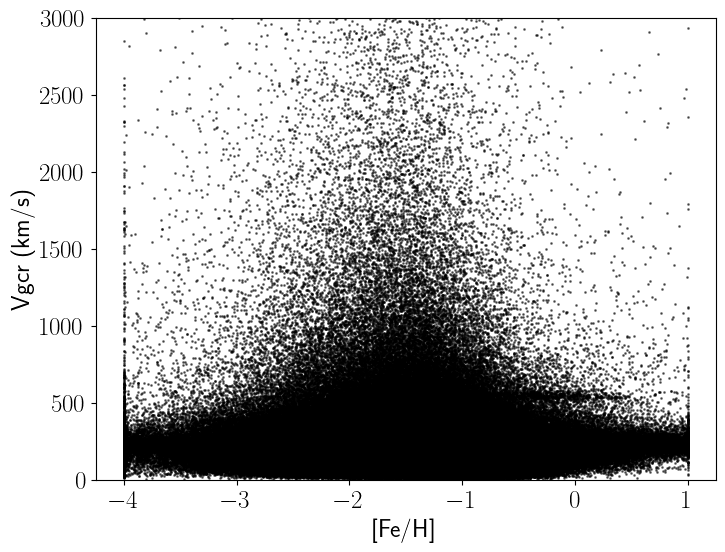

In [60]:
# FEH vs Vgcr desi
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
ax.scatter(processed['FEH'], processed['V_gcr_desi'], s=1, color='k', alpha=0.5)
#cbar = ax.scatter(processed_consistent['FEH'], processed_consistent['V_gcr_desi'], s=1, c=processed_consistent['FEH'], alpha=1)
#plt.colorbar(cbar, label='[Fe/H]', orientation='vertical', pad=0.01)
ax.set_ylabel(r'Vgcr (km/s)')
ax.set_xlabel(r'[Fe/H]')
ax.set_ylim(0, 3000)
#ax.set_xlim(0, 500)
#ax.set_ylim(-5, 0)
plt.show()


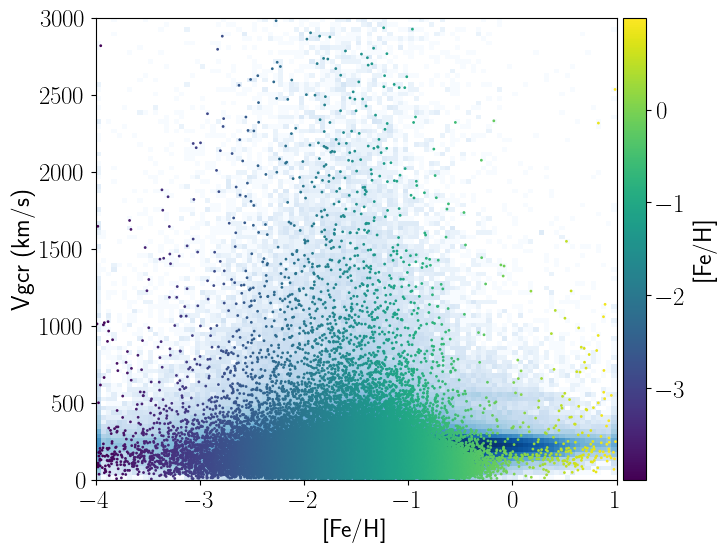

In [68]:
# FEH vs Vgcr desi
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
ax.hist2d(processed['FEH'], processed['V_gcr_desi'], bins=100, cmap='Blues', range=[[-4, 1], [0, 3000]], cmin=1, norm = 'log')
cbar = ax.scatter(processed_consistent['FEH'], processed_consistent['V_gcr_desi'], s=1, c=processed_consistent['FEH'], alpha=1)
plt.colorbar(cbar, label='[Fe/H]', orientation='vertical', pad=0.01)
ax.set_ylabel(r'Vgcr (km/s)')
ax.set_xlabel(r'[Fe/H]')
ax.set_ylim(0, 3000)
#ax.set_xlim(0, 500)
#ax.set_ylim(-5, 0)
plt.show()


In [73]:
processed_consistent_fast = processed_consistent[processed_consistent['V_gcr_desi'] > 500]

In [74]:
processed_consistent_fast = processed_consistent_fast[processed_consistent_fast['RR_SPECTYPE'] == 'STAR']

In [76]:
processed_consistent_fast[processed_consistent_fast['FEH']>0] 

TARGETID_1,SOURCE_ID,ra,dec,pmra,pmra_error,pmdec,pmdec_error,VRAD_1,DIST,DISTERR,MG_NN,MG_GEO,parallax,parallax_error,PARALLAX_ZPC,EBV,A_G,RUWE,APS,NEUIA,P_COLOUR,ECL_LAT,BINARY_FLAG,VRAD_2,VRAD_ERR,VRAD_SKEW,VRAD_KURT,LOGG,TEFF,ALPHAFE,FEH,LOGG_ERR,TEFF_ERR,ALPHAFE_ERR,FEH_ERR,VSINI,CHISQ_TOT,CHISQ_C_TOT,CHISQ_B,CHISQ_C_B,CHISQ_R,CHISQ_C_R,CHISQ_Z,CHISQ_C_Z,RVS_WARN,REF_ID,REF_CAT,TARGET_RA,TARGET_DEC,TARGETID_2,SN_B,SN_R,SN_Z,SUCCESS,RR_Z,RR_SPECTYPE,HEALPIX,SURVEY,PROGRAM,PRIMARY,implied_parallax,implied_parallax_error,VGCR,VR,implied_distance,implied_distance_error,x,y,z,vx,vy,vz,V_gcr_desi,Lz,Lx,Ly,kinetic_energy,R,potential_energy,total_energy
,,deg,deg,mas / yr,mas / yr,mas / yr,mas / yr,km / s,kpc,kpc,,,mas,mas,mas,,,,,,,,,km / s,km / s,,,,K,,,,K,,,km / s,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,bytes2,float64,float64,int64,float32,float32,float32,bool,float64,bytes6,int64,bytes7,bytes6,bool,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
39628476692566821,4598951302956298368,263.3058425405136,29.794507997767457,-11.9902626510322,0.29523181915283203,-49.218632030102484,0.3276444971561432,-187.68608291022588,16.003302780214437,9.025269057719733,3.632193088531494,10.37218332820881,1.3924782674795124,0.2957333028316498,0.003283000085502863,0.04699200019240379,0.15337081571018096,0.8886720538139343,31.0,1.831005573272705,--,53.0091056500324,1,-187.68608291022588,73.65382418902242,0.41862846550755234,2.979278276462034,6.49999978117487,14619.160211195252,1.199997938588599,0.9172299970847692,0.0007927861188093897,1885.1411450624296,0.00021853059917058607,0.09187766939239254,500.0,7503.4418794062985,7783.414779208537,2515.2813955585852,2759.1012369887394,2098.605003961287,2131.482610823239,2889.555479886427,2892.830931396558,0,4598951302956298368,G2,263.3058444923736,29.794514823896062,39628476692566821,4.7448163,3.805736,2.7572181,True,-0.00038334107207784726,STAR,32677,main,bright,True,0.5243970913982633,0.010539639129058765,-360.45552076796105,-70.23803257706675,1906.9518431797155,38.327032306789455,0.18680013102342308,11.275612233040041,7.762282520710472,3061.102061459885,-2087.835630484007,-253.08765282333974,3713.954336095712,-34.90580782011095,13.352651786416297,23.80841583248867,6896728.40530207,11.277159461443851,-0.8258963425181829,6896727.579405728
39628502831466546,4597910512121657344,266.5950058985441,31.11198398417269,-1.7821837762613377,0.2144872546195984,-0.3723596587771853,0.2177765667438507,-73.72906950465271,87.37984006111316,56.592036448331385,-0.6042828559875488,--,-0.07192005799730714,0.23010987043380737,-0.0047690002247691154,0.055590998381376266,0.17179518648938163,1.0421959161758423,31.0,1.748551607131958,--,54.49191519595743,1,-73.72906950465271,9.64521721676766,-0.06686443044412299,3.0081923350411803,3.74925748775738,13243.70517258703,-0.39999962809623496,0.012355893464144176,0.11369342012583535,386.2146967847536,0.00023897038576765366,0.2922628169833493,0.01,7668.7874353854,8766.792789768948,2681.952376906456,3639.1698447061713,2042.7390005877712,2076.6422067174567,2944.096057891174,3050.980738345321,0,4597910512121657344,G2,266.59500620005224,31.11198401500355,39628502831466546,8.119457,6.3856196,4.6024485,True,-0.00024147390780282211,STAR,32670,main,bright,True,0.07000607124321613,0.008431233239042334,123.639496450807,-90.09599847689302,14284.475363940724,1720.3614108313366,35.60430239879171,64.7502919246127,39.1443089494008,113.29720494182281,-258.24773912152165,564.7816240459025,631.2736603636604,-16.53075769171263,46.6787